In [1]:
## EDA & DAta Cleaning 

The 6 Key Phases:
Ask Questions (Business Understanding)
Data Collection
Data Cleaning
Exploratory Data Analysis (EDA)
Modeling / Analysis
Communication (Visualization & Reporting)

Steps in EDA
1. Understand Your Data

Ask:

What does each column mean?
What type of data is it? (number, text)

Example:

Age → Number
Name → Text



2. Check Data Quality

Look for:

Missing values (empty cells)
Wrong values (e.g., Age = 200)



3. Summary Statistics

Basic calculations:

Mean (Average)
Median (Middle value)
Max/Min

Example:

Average score = (80 + 90 + 65) ÷ 3 = 78.3



4. Find Patterns

Look for relationships:

Do older students score higher?
Do some students always perform better?



5. Visualize Data 📊

Charts make data easier to understand:

Bar chart → compare values
Line chart → trends over time
Pie chart → proportions

In [2]:
import pandas as pd

coding_cloass = {
    "Name": ["Gideon", "Obi", "Paul", "Susan", "Noah", "Nath"],
    "Age": [15, 14, 15, 14, 13, 10],
    "Score": [80, 90, 65, 70, 75, 80]
}

df = pd.DataFrame(coding_cloass)

# Summary
print(df.describe())

             Age      Score
count   6.000000   6.000000
mean   13.500000  76.666667
std     1.870829   8.755950
min    10.000000  65.000000
25%    13.250000  71.250000
50%    14.000000  77.500000
75%    14.750000  80.000000
max    15.000000  90.000000


In [3]:
# Average score
print(df["Score"].mean())

76.66666666666667


In [4]:
import pandas as pd
df = pd.read_csv(r"C:\Users\PAUL\Desktop\dataset\proxyskill_student.csv")

In [5]:
df.head()

,Name,Age,Study_Hours,Attendance_%,Assignment_Score,Final_Score
0,Noah,14,12,90,99,96
1,Obi,18,10,96,87,89
2,Gift,16,9,81,92,94
3,Nathaniel,19,11,93,83,90
4,Gideon,13,13,88,96,91


In [6]:
df.describe()

,Age,Study_Hours,Attendance_%,Assignment_Score,Final_Score
count,100.000000,100.000000,100.00000,100.000000,100.000000
mean,15.840000,6.220000,76.12000,73.620000,67.620000
std,1.988452,3.037077,14.51386,16.785504,16.301936
min,13.000000,1.000000,50.00000,40.000000,29.000000
25%,14.000000,4.000000,63.75000,59.750000,55.000000
50%,16.000000,6.000000,76.00000,74.000000,67.000000
75%,17.250000,9.000000,90.00000,87.000000,80.250000
max,19.000000,14.000000,100.00000,100.000000,99.000000


What This Data Represents

This is a School performance dataset used to analyze:

How study habits affect results
Impact of attendance on performance
Relationship between assignments and final score

## TASKS

Typical Questions You Can Answer
Does more study time = higher score?
Do students with high attendance perform better?
Which factor affects score the most?

In [7]:
## To check for missing values in this data

df.isnull().sum()

Name                0
Age                 0
Study_Hours         0
Attendance_%        0
Assignment_Score    0
Final_Score         0
dtype: int64

In [8]:
## To fill if there is any missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
## To remove duplicates in data
df.drop_duplicates(inplace=True)

In [11]:
df.dtypes

Name                object
Age                  int64
Study_Hours          int64
Attendance_%         int64
Assignment_Score     int64
Final_Score          int64
dtype: object

In [12]:
## To fix data type issues
##  df["Age"] = df["Age"].astype(int)

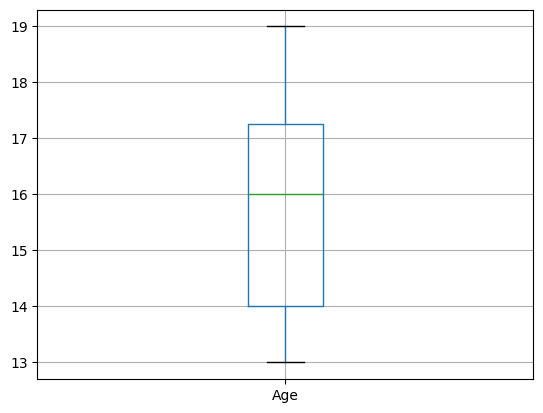

In [ ]:
## To check for outliers

import matplotlib.pyplot as plt

df.boxplot(column="Age")
plt.show()

In [14]:
### Removal of outliers if any
##  df = df[df["Final_Score"] < 100]

In [15]:
## To add a new column 
df["Performance"] = df["Final_Score"].apply(
    lambda x: "Good" if x >= 70 else "Average" if x >= 50 else "Poor"
)

In [16]:
df.head()

,Name,Age,Study_Hours,Attendance_%,Assignment_Score,Final_Score,Performance
0,Noah,14,12,90,99,96,Good
1,Obi,18,10,96,87,89,Good
2,Gift,16,9,81,92,94,Good
3,Nathaniel,19,11,93,83,90,Good
4,Gideon,13,13,88,96,91,Good


In [17]:
df.describe()

,Age,Study_Hours,Attendance_%,Assignment_Score,Final_Score
count,100.000000,100.000000,100.00000,100.000000,100.000000
mean,15.840000,6.220000,76.12000,73.620000,67.620000
std,1.988452,3.037077,14.51386,16.785504,16.301936
min,13.000000,1.000000,50.00000,40.000000,29.000000
25%,14.000000,4.000000,63.75000,59.750000,55.000000
50%,16.000000,6.000000,76.00000,74.000000,67.000000
75%,17.250000,9.000000,90.00000,87.000000,80.250000
max,19.000000,14.000000,100.00000,100.000000,99.000000


In [18]:
## Scores distribution
import matplotlib.pyplot as plt

df["Final_Score"].hist()

<Axes: >

In [19]:
## Correllations
df.corr(numeric_only=True)

,Age,Study_Hours,Attendance_%,Assignment_Score,Final_Score
Age,1.000000,-0.052654,-0.053578,0.128292,-0.049259
Study_Hours,-0.052654,1.000000,0.143303,0.114002,0.920401
Attendance_%,-0.053578,0.143303,1.000000,0.065906,0.374600
Assignment_Score,0.128292,0.114002,0.065906,1.000000,0.289796
Final_Score,-0.049259,0.920401,0.374600,0.289796,1.000000


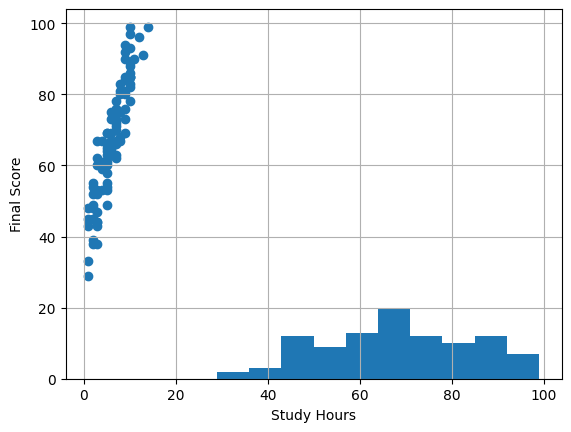

In [20]:
## Scatter plot to show study hours vs final score
import matplotlib.pyplot as plt

plt.scatter(df["Study_Hours"], df["Final_Score"])
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.show()

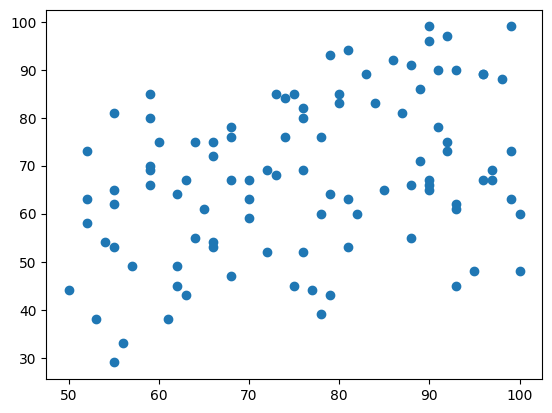

In [21]:
plt.scatter(df["Attendance_%"], df["Final_Score"])
plt.show()

In [22]:
top_students = df.sort_values(by="Final_Score", ascending=False)
top_students.head()

,Name,Age,Study_Hours,Attendance_%,Assignment_Score,Final_Score,Performance
5,Paul,16,14,90,99,99,Good
88,Kevin Gonzalez,18,10,99,72,99,Good
24,Jennifer Mitchell,16,10,92,81,97,Good
0,Noah,14,12,90,99,96,Good
2,Gift,16,9,81,92,94,Good


In [23]:
## Study hours vs final score relationship
df.groupby("Study_Hours")["Final_Score"].mean()

Study_Hours
1     39.600000
2     47.222222
3     51.000000
4     60.000000
5     60.857143
6     67.100000
7     71.076923
8     75.666667
9     82.400000
10    87.714286
11    90.000000
12    96.000000
13    91.000000
14    99.000000
Name: Final_Score, dtype: float64

In [24]:
df["Performance"].value_counts()

Performance
Good       42
Average    41
Poor       17
Name: count, dtype: int64

In [25]:
df_clean = df.drop(columns=["Performance", "Name"])

df_clean.head()

,Age,Study_Hours,Attendance_%,Assignment_Score,Final_Score
0,14,12,90,99,96
1,18,10,96,87,89
2,16,9,81,92,94
3,19,11,93,83,90
4,13,13,88,96,91


df.groupby("Study_Hours")["Final_Score"].mean().plot(kind="bar")

df.sort_values("Study_Hours").plot(x="Study_Hours", y="Final_Score", kind="line")

df.boxplot(column="Final_Score")

df["Performance"].value_counts().plot(kind="pie", autopct="%1.1f%%")

import seaborn as sns

sns.pairplot(df)

import seaborn as sns

sns.violinplot(y=df["Final_Score"])

import seaborn as sns

sns.countplot(x=df["Performance"])



In [26]:
## To save file 
# df.to_excel("students.xlsx", index=False)